In [14]:
!pip install keras-facenet

import numpy as np
import cv2
import tensorflow as tf
from keras_facenet import FaceNet
from google.colab import drive,files
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

In [15]:
from datasets import load_dataset

ds = load_dataset("tonyassi/celebrity-1000")

In [16]:
drive.mount('/content/drive')
embedder = FaceNet()
model = tf.keras.models.load_model('/content/drive/My Drive/classifier.h5')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
def resize_to_160(img):
    """
    img: Tensor or numpy array of shape (256, 256, 3)
    returns: Tensor (160, 160, 3)
    """
    img = tf.image.resize(img, (160, 160), method='bilinear')
    img = img.numpy()
    return img

In [18]:
def get_embedding(img):
  """
  The embedder.embeddings function expects a list of numpy arrays.
  img is already a numpy array from resize_to_160, so we wrap it in a list.
  """
  img = resize_to_160(img)
  emb = embedder.embeddings([img])[0]
  #emb = np.expand_dims(emb, axis=0)
  return emb

In [19]:
input_layer = tf.keras.Input(shape=(160, 160, 3))
preprocessing = tf.keras.layers.Lambda(lambda x: (x - 127.5) / 127.5)(input_layer)
facenet_base = embedder.model
facenet_base.trainable = False
embedding = facenet_base(preprocessing)
final_output = model(embedding)
full_model = tf.keras.Model(inputs=input_layer, outputs=final_output, name="End_to_End_Corrected")
full_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [20]:
def get_prediction(img):
  emb = get_embedding(img)
  emb = np.expand_dims(emb, axis=0)
  predictions = model.predict(emb)
  predicted_class = np.argmax(predictions)
  print(f"\nPredicted Class Index: {predicted_class}")
  print(f"Name: {ds['train'].features['label'].names[predicted_class]}")
  print(f"Confidence: {np.max(predictions) * 100:.2f}%")
  predictions = np.sort(predictions)[0,::-1]
  print(f"Top 10 Probabilities: {predictions[:10]}")
  return predicted_class

In [21]:
def get_occlusion_heatmap(full_model, img, true_label_index, patch_size=20, step=5):
    if img.shape[0] != 160:
        img = cv2.resize(img, (160, 160))

    input_img = np.expand_dims(img, axis=0)
    baseline_pred = full_model.predict(input_img, verbose=0)[0]
    baseline_score = baseline_pred[true_label_index]

    heatmap = np.zeros((160, 160))
    h, w, _ = img.shape


    for y in range(0, h - patch_size, step):
        for x in range(0, w - patch_size, step):
            occluded_img = img.copy()
            occluded_img[y:y+patch_size, x:x+patch_size] = 127
            input_occ = np.expand_dims(occluded_img, axis=0)
            occ_pred = full_model.predict(input_occ, verbose=0)[0]

            score = occ_pred[true_label_index]

            importance = baseline_score - score
            heatmap[y:y+patch_size, x:x+patch_size] = importance

    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)

    return heatmap

In [27]:
def visualize_occlusion_heatmap(label, img):


  test_img = np.array(img)

  heatmap = get_occlusion_heatmap(full_model, test_img, label, patch_size=30, step=10)

  plt.figure(figsize=(10, 5))



  plt.subplot(1, 2, 1)
  plt.imshow(test_img)
  heatmap_resized = cv2.resize(heatmap, (test_img.shape[1], test_img.shape[0]))

  plt.imshow(heatmap_resized, cmap='jet', alpha=0.5)
  plt.title("Importance Heatmap (Red = Crucial)")
  plt.axis('off')

  plt.tight_layout()
  plt.show()

In [28]:
def make_gradcam_heatmap(img_array, facenet_model, classifier_model):
    last_conv_layer_name = None

    for layer in reversed(facenet_model.layers):
        if 'Conv2D' in layer.__class__.__name__:
            last_conv_layer_name = layer.name
            print(f"Success! Targeting Conv Layer: {layer.name}")
            break

    if not last_conv_layer_name:
        print("Error: No Conv2D layer found. Here are the last 5 layers:")
        for layer in facenet_model.layers[-5:]:
            print(f"- {layer.name} ({layer.__class__.__name__})")
        return None

    grad_model = tf.keras.Model(
        inputs=facenet_model.inputs,
        outputs=[facenet_model.get_layer(last_conv_layer_name).output, facenet_model.output]
    )

    with tf.GradientTape() as tape:
        preprocessed_img = (tf.cast(img_array, tf.float32) - 127.5) / 127.5

        conv_outputs, embeddings = grad_model(preprocessed_img)
        preds = classifier_model(embeddings)

        top_pred_index = tf.argmax(preds[0])
        loss = preds[:, top_pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [29]:
def grad_cam(img):
  test_img = np.array(img)

  if test_img.shape[0] != 160:
      test_img = cv2.resize(test_img, (160, 160))
  img_batch = np.expand_dims(test_img, axis=0)

  heatmap = make_gradcam_heatmap(img_batch, embedder.model, model)

  if heatmap is not None:
      plt.figure(figsize=(12, 6))


      plt.subplot(1, 1, 1)
      plt.imshow(test_img)
      heatmap_resized = cv2.resize(heatmap, (160, 160))
      plt.imshow(heatmap_resized, cmap='jet', alpha=0.6)
      plt.title("Grad-CAM Heatmap\n(Where the model is looking)")
      plt.axis('off')

      plt.tight_layout()
      plt.show()

In [30]:
from mtcnn import MTCNN
import numpy as np
import cv2

detector = MTCNN()

def crop_face_mtcnn(img, required_size=(160, 160)):
    """
    Detects a face using MTCNN and returns a cropped RGB face.
    The input MUST be an RGB uint8 numpy array.
    """

    results = detector.detect_faces(img)
    if len(results) == 0:
        return None

    x, y, w, h = results[0]['box']

    x = max(0, x)
    y = max(0, y)
    x2 = min(x + w, img.shape[1])
    y2 = min(y + h, img.shape[0])

    face = img[y:y2, x:x2]

    if face.size == 0:
        return None

    face = cv2.resize(face, required_size)

    return face


Saving image.jpg to image (3).jpg


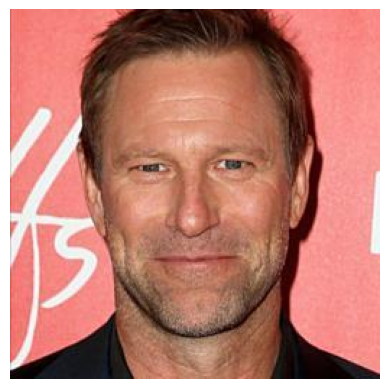

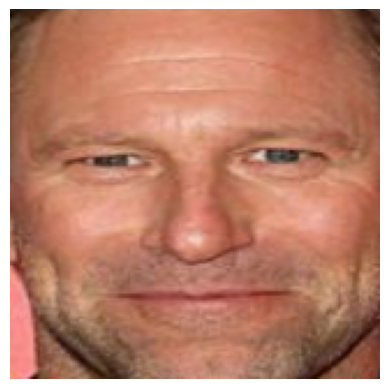

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Predicted Class Index: 0
Name: Aaron Eckhart
Confidence: 53.51%
Top 10 Probabilities: [0.5351239  0.08559132 0.06112682 0.05895093 0.05786556 0.0499972
 0.04871608 0.03799338 0.03324411 0.03139071]
Success! Targeting Conv Layer: Block8_6_Conv2d_1x1


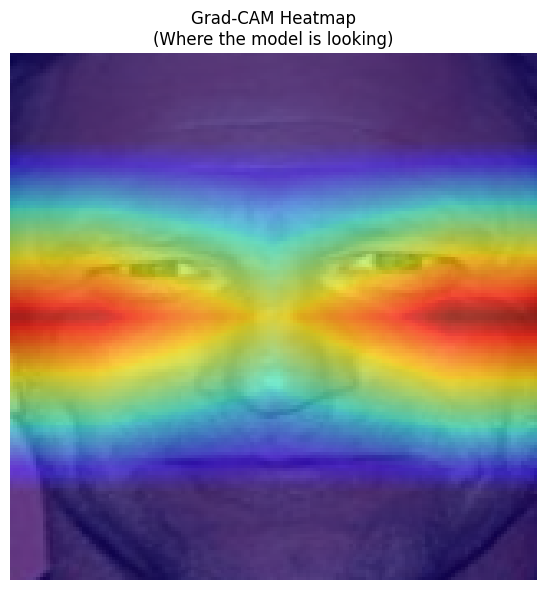

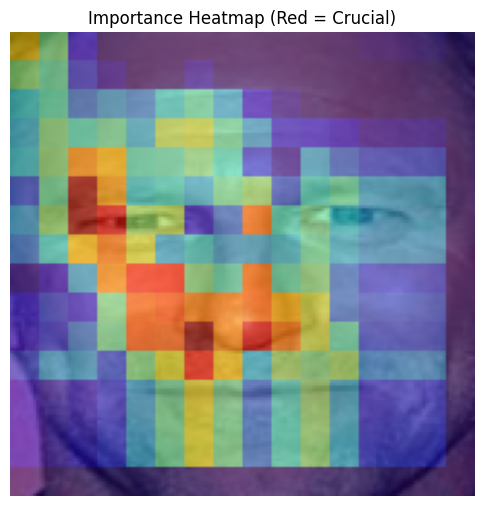

In [31]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img_pil = load_img(filename)
img = np.array(img_pil).astype('uint8')

plt.imshow(img)
plt.axis('off')
plt.show()

cropped = crop_face_mtcnn(img)

if cropped is not None:
  cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
  plt.imshow(cropped)
  plt.axis('off')
  plt.show()
else:
  print("No face detected")

if cropped is None:
  print("No face detected")
else:
  pred_class = get_prediction(cropped)
  grad_cam(cropped)
  visualize_occlusion_heatmap(pred_class,cropped)